# Introduction

In this notebook, we will do a comprehensive analysis of the Android app market by comparing thousands of apps in the Google Play store.

# About the Dataset of Google Play Store Apps & Reviews

**Data Source:** <br>
App and review data was scraped from the Google Play Store by Lavanya Gupta in 2018. Original files listed [here](
https://www.kaggle.com/lava18/google-play-store-apps).

# Import Statements

In [2]:
import pandas as pd

# Notebook Presentation

In [3]:
# Show numeric output in decimal format e.g., 2.15
pd.options.display.float_format = '{:,.2f}'.format

# Read the Dataset

In [4]:
df_apps = pd.read_csv('apps.csv')

# Data Cleaning

**Challenge**: How many rows and columns does `df_apps` have? What are the column names? Look at a random sample of 5 different rows with [.sample()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html).

In [5]:
df_apps.shape

(10841, 12)

In [6]:
df_apps.describe()

,Rating,Reviews,Size_MBs
count,"9,367.00","10,841.00","10,841.00"
mean,4.19,"444,111.93",19.77
std,0.52,"2,927,628.66",21.40
min,1.00,0.00,0.01
25%,4.00,38.00,4.90
50%,4.30,"2,094.00",11.00
75%,4.50,"54,768.00",27.00
max,5.00,"78,158,306.00",100.00


In [7]:
df_apps.sample(5)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Last_Updated,Android_Ver
5776,Millionaire : Who want to be?,GAME,4.40,4396,40.00,"100,000",Free,0,Everyone,Trivia,"April 12, 2017",2.3 and up
2456,EZ LED,TOOLS,2.20,19,2.10,"1,000",Free,0,Everyone,Tools,"September 5, 2017",4.3 and up
9879,Space Shooter : Galaxy Attack,GAME,4.60,169661,40.00,"10,000,000",Free,0,Everyone,Arcade,"August 1, 2018",4.1 and up
1007,2017 BN SM Sales Conference,BUSINESS,NaN,2,10.00,100,Free,0,Teen,Business,"September 28, 2017",4.1 and up
9194,BEYBLADE BURST app,GAME,4.50,216849,36.00,"10,000,000",Free,0,Everyone,Action;Action & Adventure,"July 16, 2018",Varies with device


### Drop Unused Columns

**Challenge**: Remove the columns called `Last_Updated` and `Android_Version` from the DataFrame. We will not use these columns. 

In [8]:
df_apps = df_apps.drop(columns=["Last_Updated","Android_Ver"])

In [9]:
df_apps.head()

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
0,Ak Parti Yardım Toplama,SOCIAL,NaN,0,8.70,0,Paid,$13.99,Teen,Social
1,Ain Arabic Kids Alif Ba ta,FAMILY,NaN,0,33.00,0,Paid,$2.99,Everyone,Education
2,Popsicle Launcher for Android P 9.0 launcher,PERSONALIZATION,NaN,0,5.50,0,Paid,$1.49,Everyone,Personalization
3,Command & Conquer: Rivals,FAMILY,NaN,0,19.00,0,NaN,0,Everyone 10+,Strategy
4,CX Network,BUSINESS,NaN,0,10.00,0,Free,0,Everyone,Business


### Find and Remove NaN values in Ratings

**Challenge**: How may rows have a NaN value (not-a-number) in the Ratings column? Create DataFrame called `df_apps_clean` that does not include these rows. 

In [10]:
df_apps.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size_MBs             0
Installs             0
Type                 1
Price                0
Content_Rating       0
Genres               0
dtype: int64

In [11]:
df_apps_clean = df_apps.dropna()

In [12]:
df_apps_clean.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size_MBs          0
Installs          0
Type              0
Price             0
Content_Rating    0
Genres            0
dtype: int64

### Find and Remove Duplicates

**Challenge**: Are there any duplicates in data? Check for duplicates using the [.duplicated()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.duplicated.html) function. How many entries can you find for the "Instagram" app? Use [.drop_duplicates()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html) to remove any duplicates from `df_apps_clean`. 


In [13]:
df_apps_clean.duplicated()

21       False
28       False
47       False
82       False
99       False
         ...  
10836    False
10837    False
10838    False
10839     True
10840    False
Length: 9367, dtype: bool

In [14]:
df_apps_clean.drop_duplicates(subset=["App","Type","Price"],inplace=True)

In [15]:
df_apps_clean

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0,Everyone,Medical
28,Ra Ga Ba,GAME,5.00,2,20.00,1,Paid,$1.49,Everyone,Arcade
47,Mu.F.O.,GAME,5.00,2,16.00,1,Paid,$0.99,Everyone,Arcade
82,Brick Breaker BR,GAME,5.00,7,19.00,5,Free,0,Everyone,Arcade
99,Anatomy & Physiology Vocabulary Exam Review App,MEDICAL,5.00,1,4.60,5,Free,0,Everyone,Medical
...,...,...,...,...,...,...,...,...,...,...
10824,Google Drive,PRODUCTIVITY,4.40,2731171,4.00,"1,000,000,000",Free,0,Everyone,Productivity
10828,YouTube,VIDEO_PLAYERS,4.30,25655305,4.65,"1,000,000,000",Free,0,Teen,Video Players & Editors
10829,Google Play Movies & TV,VIDEO_PLAYERS,3.70,906384,4.65,"1,000,000,000",Free,0,Teen,Video Players & Editors
10831,Google News,NEWS_AND_MAGAZINES,3.90,877635,13.00,"1,000,000,000",Free,0,Teen,News & Magazines


# Find Highest Rated Apps

**Challenge**: Identify which apps are the highest rated. What problem might you encounter if you rely exclusively on ratings alone to determine the quality of an app?

In [16]:
df_apps_clean.sort_values(by="Rating",ascending=False)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0,Everyone,Medical
1751,Spine- The dating app,DATING,5.00,5,9.30,500,Free,0,Teen,Dating
1761,Selfie With Champion AJ Style,PHOTOGRAPHY,5.00,2,7.50,500,Free,0,Everyone,Photography
1763,Ag Valley Cooperative,BUSINESS,5.00,6,74.00,500,Free,0,Everyone,Business
1769,Yazdani Cd Center EllahAbad Official App,FAMILY,5.00,8,3.80,500,Free,0,Everyone,Entertainment
...,...,...,...,...,...,...,...,...,...,...
818,Familial Hypercholesterolaemia Handbook,MEDICAL,1.00,2,33.00,100,Free,0,Everyone,Medical
1208,Thistletown CI,PRODUCTIVITY,1.00,1,6.60,100,Free,0,Everyone,Productivity
1314,CR Magazine,BUSINESS,1.00,1,7.80,100,Free,0,Everyone,Business
1679,CB Mobile Biz,FINANCE,1.00,3,8.40,500,Free,0,Everyone,Finance


# Find 5 Largest Apps in terms of Size (MBs)

**Challenge**: What's the size in megabytes (MB) of the largest Android apps in the Google Play Store. Based on the data, do you think there could be limit in place or can developers make apps as large as they please? 

In [17]:
df_apps_clean.sort_values(by="Size_MBs",ascending=False)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
8719,Draft Simulator for FUT 18,SPORTS,4.60,162933,100.00,"5,000,000",Free,0,Everyone,Sports
8718,Mini Golf King - Multiplayer Game,GAME,4.50,531458,100.00,"5,000,000",Free,0,Everyone,Sports
10295,SimCity BuildIt,FAMILY,4.50,4218587,100.00,"50,000,000",Free,0,Everyone 10+,Simulation
9945,Ultimate Tennis,SPORTS,4.30,183004,100.00,"10,000,000",Free,0,Everyone,Sports
9944,Gangster Town: Vice District,FAMILY,4.30,65146,100.00,"10,000,000",Free,0,Mature 17+,Simulation
...,...,...,...,...,...,...,...,...,...,...
5798,ExDialer PRO Key,COMMUNICATION,4.50,5474,0.02,"100,000",Paid,$3.99,Everyone,Communication
2648,Ad Remove Plugin for App2SD,PRODUCTIVITY,4.10,66,0.02,"1,000",Paid,$1.29,Everyone,Productivity
2684,My baby firework (Remove ad),FAMILY,4.10,30,0.01,"1,000",Paid,$0.99,Everyone,Entertainment
7966,Market Update Helper,LIBRARIES_AND_DEMO,4.10,20145,0.01,"1,000,000",Free,0,Everyone,Libraries & Demo


# Find the 5 App with Most Reviews

**Challenge**: Which apps have the highest number of reviews? Are there any paid apps among the top 50?

In [18]:
df_apps_clean.sort_values(by="Reviews",ascending=False)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
10805,Facebook,SOCIAL,4.10,78158306,5.30,"1,000,000,000",Free,0,Teen,Social
10785,WhatsApp Messenger,COMMUNICATION,4.40,69119316,3.50,"1,000,000,000",Free,0,Everyone,Communication
10806,Instagram,SOCIAL,4.50,66577313,5.30,"1,000,000,000",Free,0,Teen,Social
10784,Messenger – Text and Video Chat for Free,COMMUNICATION,4.00,56642847,3.50,"1,000,000,000",Free,0,Everyone,Communication
10650,Clash of Clans,GAME,4.60,44891723,98.00,"100,000,000",Free,0,Everyone 10+,Strategy
...,...,...,...,...,...,...,...,...,...,...
728,Truck Driving Test Class 3 BC,FAMILY,1.00,1,2.00,50,Paid,$1.49,Everyone,Education
485,Familyfirst Messenger,MEDICAL,4.00,1,3.30,10,Free,0,Everyone,Medical
617,DT future1 cam,TOOLS,1.00,1,24.00,50,Free,0,Everyone,Tools
496,CI 174 Gray Icon Pack,PERSONALIZATION,5.00,1,46.00,10,Paid,$0.99,Everyone,Personalization


# Plotly Pie and Donut Charts - Visualise Categorical Data: Content Ratings

In [19]:
rating = df_apps_clean["Content_Rating"].value_counts()
rating

Content_Rating
Everyone           6621
Teen                912
Mature 17+          357
Everyone 10+        305
Adults only 18+       3
Unrated               1
Name: count, dtype: int64

In [20]:
import plotly.express as px

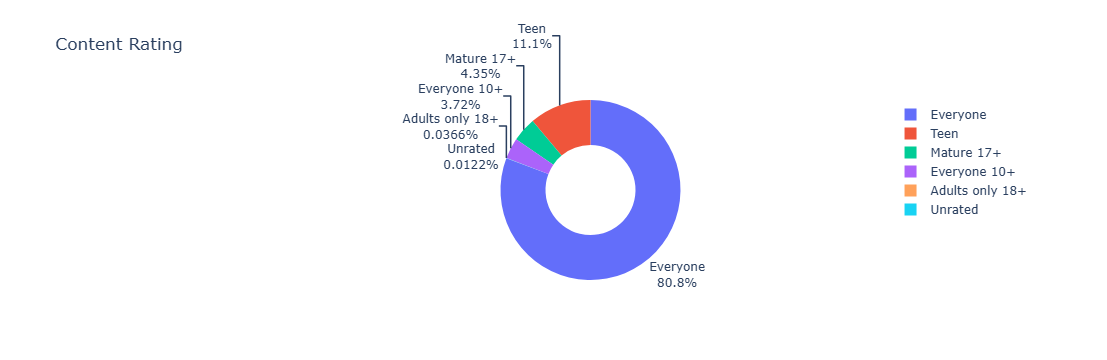

In [21]:
fig = px.pie(names=rating.index, values=rating.values, labels=rating.index, title="Content Rating", hole=0.5)
fig.update_traces(textposition='outside',textinfo='percent+label')
fig.show()


# Numeric Type Conversion: Examine the Number of Installs

**Challenge**: How many apps had over 1 billion (that's right - BILLION) installations? How many apps just had a single install? 

Check the datatype of the Installs column.

Count the number of apps at each level of installations. 

Convert the number of installations (the Installs column) to a numeric data type. Hint: this is a 2-step process. You'll have make sure you remove non-numeric characters first. 

In [22]:
df_apps_clean['Installs'].describe()

count          8199
unique           19
top       1,000,000
freq           1417
Name: Installs, dtype: object

In [23]:
df_apps_clean.groupby('Installs').count()

,App,Category,Rating,Reviews,Size_MBs,Type,Price,Content_Rating,Genres
Installs,,,,,,,,,
1,3,3,3,3,3,3,3,3,3
"1,000",698,698,698,698,698,698,698,698,698
"1,000,000",1417,1417,1417,1417,1417,1417,1417,1417,1417
"1,000,000,000",20,20,20,20,20,20,20,20,20
10,69,69,69,69,69,69,69,69,69
"10,000",988,988,988,988,988,988,988,988,988
"10,000,000",933,933,933,933,933,933,933,933,933
100,303,303,303,303,303,303,303,303,303
"100,000",1096,1096,1096,1096,1096,1096,1096,1096,1096


In [24]:
df_apps_clean['Installs'] = df_apps_clean['Installs'].str.replace(",","")
df_apps_clean['Installs'] = pd.to_numeric(df_apps_clean['Installs'])

# Find the Most Expensive Apps, Filter out the Junk, and Calculate a (ballpark) Sales Revenue Estimate

Let's examine the Price column more closely.

**Challenge**: Convert the price column to numeric data. Then investigate the top 20 most expensive apps in the dataset.

Remove all apps that cost more than $250 from the `df_apps_clean` DataFrame.

Add a column called 'Revenue_Estimate' to the DataFrame. This column should hold the price of the app times the number of installs. What are the top 10 highest grossing paid apps according to this estimate? Out of the top 10 highest grossing paid apps, how many are games?


In [25]:
df_apps_clean['Price'].describe()

count     8199
unique      73
top          0
freq      7595
Name: Price, dtype: object

In [26]:
df_apps_clean.sort_values(by="Price", ascending=False)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0,Everyone,Medical
7182,Pushbullet - SMS on PC,PRODUCTIVITY,4.50,176873,4.50,1000000,Free,0,Everyone,Productivity
7196,Al Quran Audio (Full 30 Juz),FAMILY,4.70,7878,3.60,1000000,Free,0,Everyone,Education
7195,Funny Quotes Free,ENTERTAINMENT,4.20,23666,3.60,1000000,Free,0,Teen,Entertainment
7194,EX File Explorer File Manager,PRODUCTIVITY,4.00,4660,5.90,1000000,Free,0,Everyone,Productivity
...,...,...,...,...,...,...,...,...,...,...
3413,BringGo AU & NZ,MAPS_AND_NAVIGATION,2.80,440,23.00,10000,Paid,$0.99,Everyone,Maps & Navigation
5997,Hitman GO,FAMILY,4.60,84114,23.00,500000,Paid,$0.99,Everyone 10+,Puzzle
1388,An Elite Warrior Ex,GAME,4.70,15,93.00,100,Paid,$0.99,Everyone,Adventure
1327,CB Frequencies,TOOLS,4.00,5,1.40,100,Paid,$0.99,Everyone,Tools


In [27]:
df_apps_clean['Price'] = df_apps_clean['Price'].str.replace("$","")
df_apps_clean['Price'] = pd.to_numeric(df_apps_clean['Price'])


In [28]:
df_apps_clean[['App',"Price"]].sort_values(by="Price",ascending=False).head(20)


,App,Price
3946,I'm Rich - Trump Edition,400.00
2394,I am Rich!,399.99
2461,I AM RICH PRO PLUS,399.99
1331,most expensive app (H),399.99
3145,I am rich(premium),399.99
2775,I Am Rich Pro,399.99
5765,I am rich,399.99
3221,I am Rich Plus,399.99
3554,💎 I'm rich,399.99
3114,I am Rich,399.99


### The most expensive apps sub $250

In [29]:
df_apps_clean = df_apps_clean[df_apps_clean['Price']<250]
df_apps_clean[['App',"Price"]].sort_values(by="Price",ascending=False).head(20)


,App,Price
2281,Vargo Anesthesia Mega App,79.99
1407,LTC AS Legal,39.99
2629,I am Rich Person,37.99
2481,A Manual of Acupuncture,33.99
504,AP Art History Flashcards,29.99
2463,PTA Content Master,29.99
2207,EMT PASS,29.99
4264,Golfshot Plus: Golf GPS,29.99
4772,Human Anatomy Atlas 2018: Complete 3D Human Body,24.99
3241,"Muscle Premium - Human Anatomy, Kinesiology, B...",24.99


### Highest Grossing Paid Apps (ballpark estimate)

In [30]:
df_apps_clean["Revenue_Estimate"] = df_apps_clean['Installs']*df_apps_clean['Price']
df_apps_clean.sort_values(by="Revenue_Estimate", ascending=False).head(10)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Revenue_Estimate
9220,Minecraft,FAMILY,4.50,2376564,19.00,10000000,Paid,6.99,Everyone 10+,Arcade;Action & Adventure,"69,900,000.00"
8825,Hitman Sniper,GAME,4.60,408292,29.00,10000000,Paid,0.99,Mature 17+,Action,"9,900,000.00"
7151,Grand Theft Auto: San Andreas,GAME,4.40,348962,26.00,1000000,Paid,6.99,Mature 17+,Action,"6,990,000.00"
7477,Facetune - For Free,PHOTOGRAPHY,4.40,49553,48.00,1000000,Paid,5.99,Everyone,Photography,"5,990,000.00"
7977,Sleep as Android Unlock,LIFESTYLE,4.50,23966,0.85,1000000,Paid,5.99,Everyone,Lifestyle,"5,990,000.00"
6594,DraStic DS Emulator,GAME,4.60,87766,12.00,1000000,Paid,4.99,Everyone,Action,"4,990,000.00"
6082,Weather Live,WEATHER,4.50,76593,4.75,500000,Paid,5.99,Everyone,Weather,"2,995,000.00"
6746,Card Wars - Adventure Time,FAMILY,4.30,129603,23.00,1000000,Paid,2.99,Everyone 10+,Card;Action & Adventure,"2,990,000.00"
7633,Five Nights at Freddy's,GAME,4.60,100805,50.00,1000000,Paid,2.99,Teen,Action,"2,990,000.00"
7954,Bloons TD 5,FAMILY,4.60,190086,94.00,1000000,Paid,2.99,Everyone,Strategy,"2,990,000.00"


# Plotly Bar Charts & Scatter Plots: Analysing App Categories

In [31]:
df_apps_clean['Category'].nunique()

33

In [32]:
top10 = df_apps_clean['Category'].value_counts()
top10

Category
FAMILY                 1606
GAME                    910
TOOLS                   719
PRODUCTIVITY            301
PERSONALIZATION         298
LIFESTYLE               297
FINANCE                 296
MEDICAL                 292
PHOTOGRAPHY             263
BUSINESS                262
SPORTS                  260
COMMUNICATION           257
HEALTH_AND_FITNESS      243
NEWS_AND_MAGAZINES      204
SOCIAL                  203
TRAVEL_AND_LOCAL        187
SHOPPING                180
BOOKS_AND_REFERENCE     169
VIDEO_PLAYERS           148
DATING                  134
MAPS_AND_NAVIGATION     118
EDUCATION               118
ENTERTAINMENT           102
FOOD_AND_DRINK           94
AUTO_AND_VEHICLES        73
WEATHER                  72
LIBRARIES_AND_DEMO       64
HOUSE_AND_HOME           62
ART_AND_DESIGN           61
COMICS                   54
PARENTING                50
EVENTS                   45
BEAUTY                   42
Name: count, dtype: int64

### Vertical Bar Chart - Highest Competition (Number of Apps)

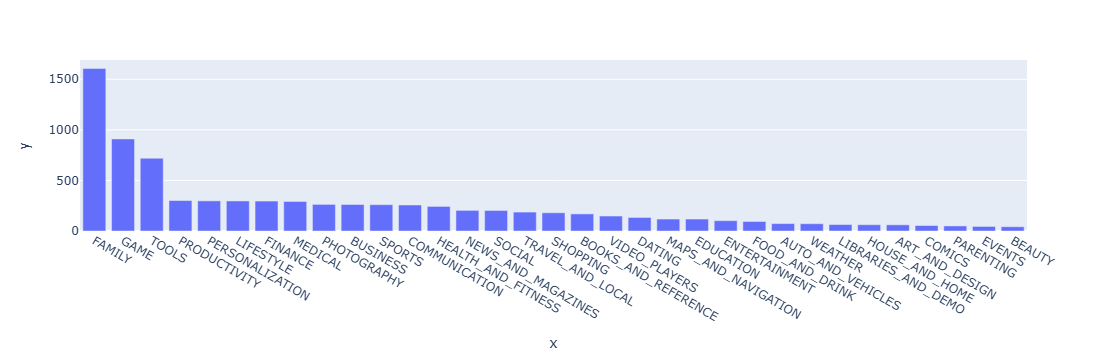

In [33]:
bar = px.bar(x=top10.index,y=top10.values)
bar.show()

### Horizontal Bar Chart - Most Popular Categories (Highest Downloads)

In [34]:
most_installed = df_apps_clean[["Category","Installs"]].groupby('Category').sum()
most_installed

,Installs
Category,
ART_AND_DESIGN,114233100
AUTO_AND_VEHICLES,53129800
BEAUTY,26916200
BOOKS_AND_REFERENCE,1665791655
BUSINESS,692018120
COMICS,44931100
COMMUNICATION,11039241530
DATING,140912410
EDUCATION,352852000


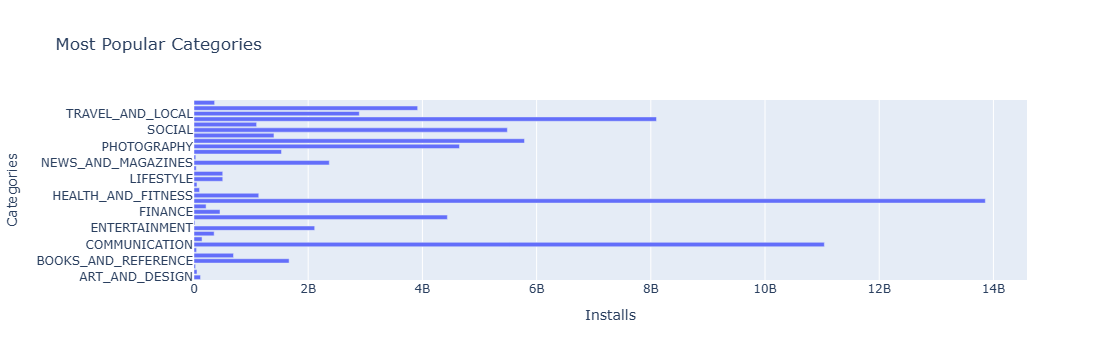

In [35]:
h_bar = px.bar(
    y = most_installed.index,
    x = most_installed.Installs,
    orientation='h',
    title="Most Popular Categories"
)
h_bar.update_layout(xaxis_title="Installs",yaxis_title="Categories")
h_bar.show()

### Category Concentration - Downloads vs. Competition

**Challenge**: 
* First, create a DataFrame that has the number of apps in one column and the number of installs in another:

<img src=https://imgur.com/uQRSlXi.png width="350">

* Then use the [plotly express examples from the documentation](https://plotly.com/python/line-and-scatter/) alongside the [.scatter() API reference](https://plotly.com/python-api-reference/generated/plotly.express.scatter.html)to create scatter plot that looks like this. 

<img src=https://imgur.com/cHsqh6a.png>

*Hint*: Use the size, hover_name and color parameters in .scatter(). To scale the yaxis, call .update_layout() and specify that the yaxis should be on a log-scale like so: yaxis=dict(type='log') 

In [36]:
df_apps_clean

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Revenue_Estimate
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0.00,Everyone,Medical,0.00
28,Ra Ga Ba,GAME,5.00,2,20.00,1,Paid,1.49,Everyone,Arcade,1.49
47,Mu.F.O.,GAME,5.00,2,16.00,1,Paid,0.99,Everyone,Arcade,0.99
82,Brick Breaker BR,GAME,5.00,7,19.00,5,Free,0.00,Everyone,Arcade,0.00
99,Anatomy & Physiology Vocabulary Exam Review App,MEDICAL,5.00,1,4.60,5,Free,0.00,Everyone,Medical,0.00
...,...,...,...,...,...,...,...,...,...,...,...
10824,Google Drive,PRODUCTIVITY,4.40,2731171,4.00,1000000000,Free,0.00,Everyone,Productivity,0.00
10828,YouTube,VIDEO_PLAYERS,4.30,25655305,4.65,1000000000,Free,0.00,Teen,Video Players & Editors,0.00
10829,Google Play Movies & TV,VIDEO_PLAYERS,3.70,906384,4.65,1000000000,Free,0.00,Teen,Video Players & Editors,0.00
10831,Google News,NEWS_AND_MAGAZINES,3.90,877635,13.00,1000000000,Free,0.00,Teen,News & Magazines,0.00


In [37]:
cat_conc = df_apps_clean.groupby("Category").agg({"Installs":pd.Series.sum,"App":pd.Series.count}).sort_values(by="Installs")
cat_conc

,Installs,App
Category,,
EVENTS,15949410,45
BEAUTY,26916200,42
PARENTING,31116110,50
MEDICAL,39162676,292
COMICS,44931100,54
LIBRARIES_AND_DEMO,52083000,64
AUTO_AND_VEHICLES,53129800,73
HOUSE_AND_HOME,97082000,62
ART_AND_DESIGN,114233100,61


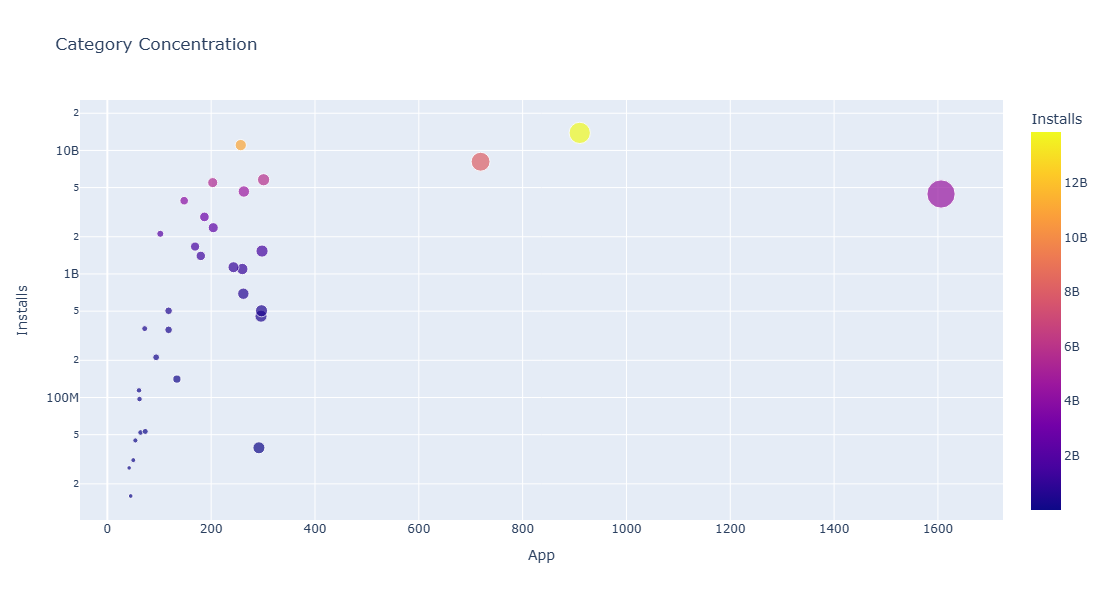

In [38]:
scatter = px.scatter(cat_conc,x="App",y="Installs",title="Category Concentration",color="Installs",log_y=True,height=600,width=800,size="App",hover_data=[cat_conc.index])
scatter.show()

# Extracting Nested Data from a Column

**Challenge**: How many different types of genres are there? Can an app belong to more than one genre? Check what happens when you use .value_counts() on a column with nested values? See if you can work around this problem by using the .split() function and the DataFrame's [.stack() method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.stack.html). 


In [39]:
df_apps_clean['Genres'].value_counts()

Genres
Tools                       718
Entertainment               467
Education                   429
Productivity                301
Personalization             298
                           ... 
Casual;Music & Video          1
Tools;Education               1
Role Playing;Brain Games      1
Adventure;Education           1
Lifestyle;Pretend Play        1
Name: count, Length: 114, dtype: int64

In [40]:
stacked_unclean = df_apps_clean['Genres'].str.split(";",expand=True).stack()
stacked_clean = stacked_unclean.dropna()
genre_count = stacked_clean.value_counts()

# Colour Scales in Plotly Charts - Competition in Genres

**Challenge**: Can you create this chart with the Series containing the genre data? 

<img src=https://imgur.com/DbcoQli.png width=400>

Try experimenting with the built in colour scales in Plotly. You can find a full list [here](https://plotly.com/python/builtin-colorscales/). 

* Find a way to set the colour scale using the color_continuous_scale parameter. 
* Find a way to make the color axis disappear by using coloraxis_showscale. 

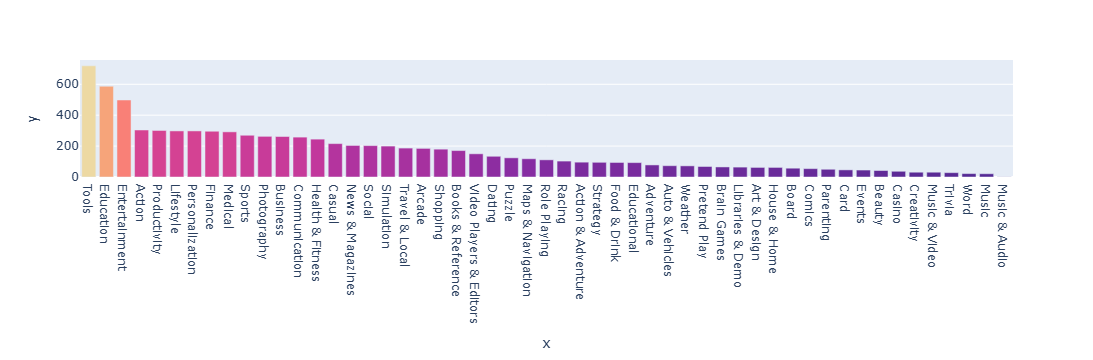

In [41]:
genre_bar = px.bar(x=genre_count.index,y=genre_count.values, color=genre_count.values ,color_continuous_scale="Agsunset")
genre_bar.update_layout(coloraxis_showscale=False)
genre_bar.show()

# Grouped Bar Charts: Free vs. Paid Apps per Category

In [42]:
df_free_vs_paid = df_apps_clean[['Category','Type']].groupby("Category",as_index=False).value_counts()
df_free_vs_paid

,Category,Type,count
0,ART_AND_DESIGN,Free,58
1,ART_AND_DESIGN,Paid,3
2,AUTO_AND_VEHICLES,Free,72
3,AUTO_AND_VEHICLES,Paid,1
4,BEAUTY,Free,42
...,...,...,...
56,TRAVEL_AND_LOCAL,Paid,8
57,VIDEO_PLAYERS,Free,144
58,VIDEO_PLAYERS,Paid,4
59,WEATHER,Free,65


**Challenge**: Use the plotly express bar [chart examples](https://plotly.com/python/bar-charts/#bar-chart-with-sorted-or-ordered-categories) and the [.bar() API reference](https://plotly.com/python-api-reference/generated/plotly.express.bar.html#plotly.express.bar) to create this bar chart: 

<img src=https://imgur.com/LE0XCxA.png>

You'll want to use the `df_free_vs_paid` DataFrame that you created above that has the total number of free and paid apps per category. 

See if you can figure out how to get the look above by changing the `categoryorder` to 'total descending' as outlined in the documentation here [here](https://plotly.com/python/categorical-axes/#automatically-sorting-categories-by-name-or-total-value). 

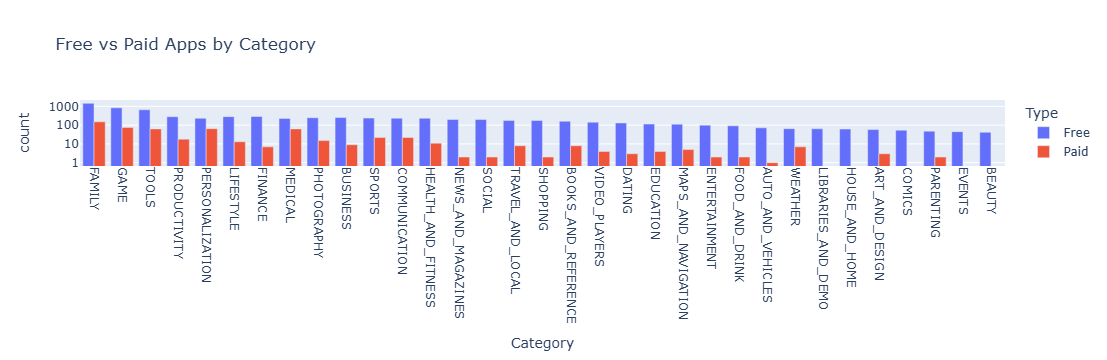

In [43]:
free_vs_paid_bar = px.bar(df_free_vs_paid,x='Category',y='count',color='Type',log_y=True,barmode='group',title="Free vs Paid Apps by Category")
free_vs_paid_bar.update_xaxes(categoryorder='total descending')
free_vs_paid_bar.update_layout(xaxis_tickangle=90)
free_vs_paid_bar.show()

# Plotly Box Plots: Lost Downloads for Paid Apps

**Challenge**: Create a box plot that shows the number of Installs for free versus paid apps. How does the median number of installations compare? Is the difference large or small?

Use the [Box Plots Guide](https://plotly.com/python/box-plots/) and the [.box API reference](https://plotly.com/python-api-reference/generated/plotly.express.box.html) to create the following chart. 

<img src=https://imgur.com/uVsECT3.png>


In [44]:
df_apps_clean

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Revenue_Estimate
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0.00,Everyone,Medical,0.00
28,Ra Ga Ba,GAME,5.00,2,20.00,1,Paid,1.49,Everyone,Arcade,1.49
47,Mu.F.O.,GAME,5.00,2,16.00,1,Paid,0.99,Everyone,Arcade,0.99
82,Brick Breaker BR,GAME,5.00,7,19.00,5,Free,0.00,Everyone,Arcade,0.00
99,Anatomy & Physiology Vocabulary Exam Review App,MEDICAL,5.00,1,4.60,5,Free,0.00,Everyone,Medical,0.00
...,...,...,...,...,...,...,...,...,...,...,...
10824,Google Drive,PRODUCTIVITY,4.40,2731171,4.00,1000000000,Free,0.00,Everyone,Productivity,0.00
10828,YouTube,VIDEO_PLAYERS,4.30,25655305,4.65,1000000000,Free,0.00,Teen,Video Players & Editors,0.00
10829,Google Play Movies & TV,VIDEO_PLAYERS,3.70,906384,4.65,1000000000,Free,0.00,Teen,Video Players & Editors,0.00
10831,Google News,NEWS_AND_MAGAZINES,3.90,877635,13.00,1000000000,Free,0.00,Teen,News & Magazines,0.00


In [45]:
df_installs = df_apps_clean[['Installs','Type','Category']].groupby(["Category","Type"],as_index=False).sum()
df_installs

,Category,Type,Installs
0,ART_AND_DESIGN,Free,114217100
1,ART_AND_DESIGN,Paid,16000
2,AUTO_AND_VEHICLES,Free,53079800
3,AUTO_AND_VEHICLES,Paid,50000
4,BEAUTY,Free,26916200
...,...,...,...
56,TRAVEL_AND_LOCAL,Paid,182000
57,VIDEO_PLAYERS,Free,3916826200
58,VIDEO_PLAYERS,Paid,71000
59,WEATHER,Free,360285000


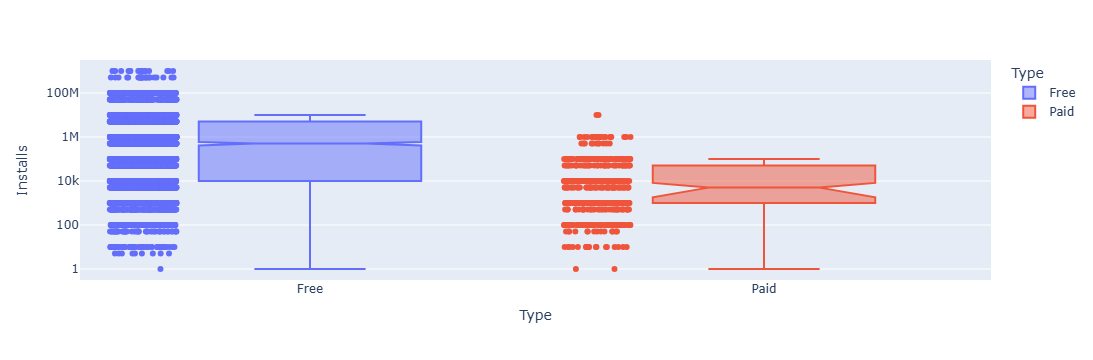

In [46]:
box = px.box(df_apps_clean, x="Type", y="Installs",log_y=True,color='Type',notched=True,points='all')
box.show()

# Plotly Box Plots: Revenue by App Category

**Challenge**: See if you can generate the chart below: 

<img src=https://imgur.com/v4CiNqX.png>

Looking at the hover text, how much does the median app earn in the Tools category? If developing an Android app costs $30,000 or thereabouts, does the average photography app recoup its development costs?

Hint: I've used 'min ascending' to sort the categories. 

In [47]:
df_apps_clean.groupby('Category').count()

,App,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Revenue_Estimate
Category,,,,,,,,,,
ART_AND_DESIGN,61,61,61,61,61,61,61,61,61,61
AUTO_AND_VEHICLES,73,73,73,73,73,73,73,73,73,73
BEAUTY,42,42,42,42,42,42,42,42,42,42
BOOKS_AND_REFERENCE,169,169,169,169,169,169,169,169,169,169
BUSINESS,262,262,262,262,262,262,262,262,262,262
COMICS,54,54,54,54,54,54,54,54,54,54
COMMUNICATION,257,257,257,257,257,257,257,257,257,257
DATING,134,134,134,134,134,134,134,134,134,134
EDUCATION,118,118,118,118,118,118,118,118,118,118


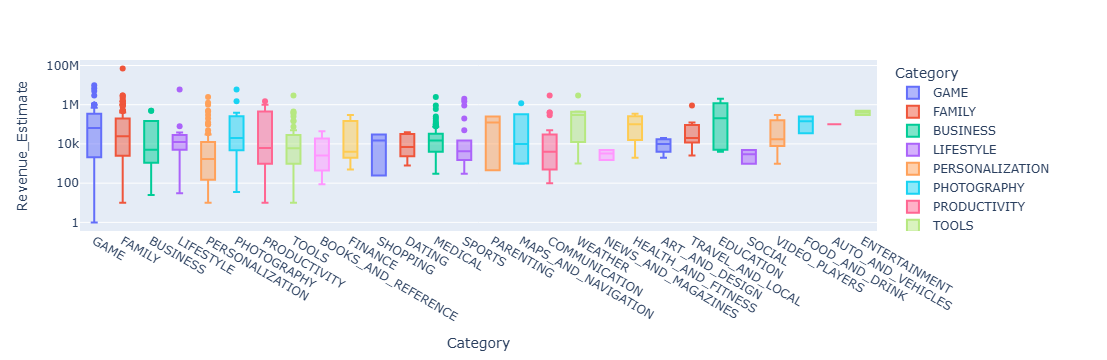

In [48]:
rev_box = px.box(df_apps_clean[df_apps_clean['Type']=="Paid"], x="Category", y="Revenue_Estimate",log_y=True,color='Category',)
fig.update_xaxes(categoryorder='min ascending')
rev_box.show()

# How Much Can You Charge? Examine Paid App Pricing Strategies by Category

**Challenge**: What is the median price price for a paid app? Then compare pricing by category by creating another box plot. But this time examine the prices (instead of the revenue estimates) of the paid apps. I recommend using `{categoryorder':'max descending'}` to sort the categories.

In [61]:
df_apps_clean["Price"][df_apps_clean['Type'] == "Paid"].median()

np.float64(2.99)

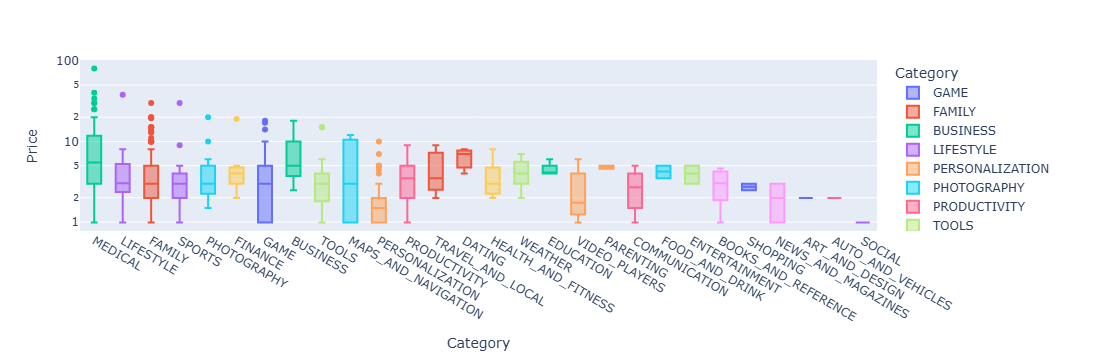

In [59]:
price_box = px.box(df_apps_clean[df_apps_clean.Type == "Paid"], x = "Category", y = "Price", color="Category", log_y=True)
price_box.update_xaxes(categoryorder = "max descending")
price_box.show()